In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error as mse 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score
from sklearn.tree import DecisionTreeRegressor

### Loading the Processed data from exploratory data analysis

In [2]:
df = pd.read_csv("./data/house_processed_data.csv")
df.head()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,lotconfig,landslope,neighborhood,...,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,60,rl,65.0,8450,pave,reg,lvl,inside,gtl,collgcr,...,0,0,0,0,0,2,2008,wd,normal,208500
1,20,rl,80.0,9600,pave,reg,lvl,fr2,gtl,veenker,...,0,0,0,0,0,5,2007,wd,normal,181500
2,60,rl,68.0,11250,pave,ir1,lvl,inside,gtl,collgcr,...,0,0,0,0,0,9,2008,wd,normal,223500
3,70,rl,60.0,9550,pave,ir1,lvl,corner,gtl,crawfor,...,272,0,0,0,0,2,2006,wd,abnorml,140000
4,60,rl,84.0,14260,pave,ir1,lvl,fr2,gtl,noridge,...,0,0,0,0,0,12,2008,wd,normal,250000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mssubclass     1397 non-null   int64  
 1   mszoning       1397 non-null   object 
 2   lotfrontage    1397 non-null   float64
 3   lotarea        1397 non-null   int64  
 4   street         1397 non-null   object 
 5   lotshape       1397 non-null   object 
 6   landcontour    1397 non-null   object 
 7   lotconfig      1397 non-null   object 
 8   landslope      1397 non-null   object 
 9   neighborhood   1397 non-null   object 
 10  condition1     1397 non-null   object 
 11  condition2     1397 non-null   object 
 12  bldgtype       1397 non-null   object 
 13  housestyle     1397 non-null   object 
 14  overallqual    1397 non-null   int64  
 15  overallcond    1397 non-null   int64  
 16  yearbuilt      1397 non-null   int64  
 17  yearremodadd   1397 non-null   int64  
 18  roofstyl

#### Getting the summary of the data 

In [4]:
df.describe()

,mssubclass,lotfrontage,lotarea,overallqual,overallcond,yearbuilt,yearremodadd,masvnrarea,bsmtfinsf1,bsmtfinsf2,...,wooddecksf,openporchsf,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saleprice
count,1397.000000,1397.000000,1397.000000,1397.00000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,...,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,57.483894,69.145669,10095.387974,5.97781,5.591983,1970.027201,1984.024338,88.738726,412.272727,47.546886,...,89.447387,44.456693,22.410165,3.236220,14.654975,2.142448,45.450251,6.313529,2007.820329,170234.066571
std,42.834148,20.913146,8166.294935,1.27414,1.118812,29.997480,20.656059,157.178994,402.199372,162.755064,...,121.798854,64.713434,61.492644,28.583263,54.788508,36.121181,507.106304,2.699978,1.328523,59270.637981
min,20.000000,21.000000,1300.000000,1.00000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7438.000000,5.00000,5.000000,1953.000000,1966.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129000.000000
50%,50.000000,70.000000,9317.000000,6.00000,5.000000,1971.000000,1992.000000,0.000000,369.000000,0.000000,...,0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,159500.000000
75%,70.000000,80.000000,11310.000000,7.00000,6.000000,1999.000000,2003.000000,142.000000,685.000000,0.000000,...,165.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,204000.000000
max,190.000000,313.000000,164660.000000,10.00000,9.000000,2009.000000,2010.000000,1600.000000,1880.000000,1474.000000,...,736.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,340000.000000


#### Checking the skewness of the target column

In [5]:
df["saleprice"].skew()

np.float64(0.6794674977938033)

### Checking for the null

In [6]:
null = (df.isna().mean() * 100).sort_values(ascending=False)
null

mssubclass     0.0
garageyrblt    0.0
fireplacequ    0.0
fireplaces     0.0
functional     0.0
              ... 
extercond      0.0
exterqual      0.0
masvnrarea     0.0
exterior2nd    0.0
saleprice      0.0
Length: 74, dtype: float64

#### Checking for duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(1397, 74)

### Checking the skewness of the target column to discover if there are outliers or not

In [9]:
df["saleprice"].skew()

np.float64(0.6794674977938033)

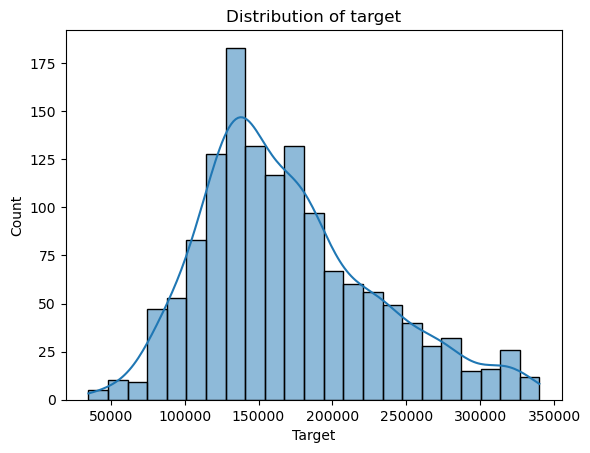

In [10]:
# Checking the distibution of the target column
sns.histplot(df["saleprice"], kde=True) 
plt.title("Distribution of target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

This shows that the target column is a litle void of outliers and is close to being normally distributed through symetrical skewness

### Conbining related features for a whole representation of the house size

In [11]:
print (df["saleprice"].max())
print (df["saleprice"].min())
print (df["saleprice"].median())

340000
34900
159500.0


#### To get more comptrehensive indicator of the house values and improve the model accuracy, some columns would be merged to create a new 1-roll columns and this would be done for four difference batch of like-columns 

For total floor area: Some existing columns would be merged into forming this column (the columns to be merged are: 2ndFlrSF, 1stFlrSF, 1stFlrSF, 1stFlrSF, TotalBsmtSF).   This is done because buyers mostly look at the size of the building as a simple comprehensive number so, sombining the like-column into forming this would bring the one column that indicate the size of the building. Also from the EDA, the area columns have linear relationship with the target column, so, their combination owuld also align with the initial discorvery of the linear relationship with the saleprice which is the target

In [12]:
df["totalsf"] = df["totalbsmtsf"] + df["1stflrsf"] + df["2ndflrsf"]

For total bathrooms: The columns that would be merged are (fullbath, halfbath, bsmtfullbath, bsmthalfbath). This column combines all full and half bathrooms from both the basement and upper floors into a single column called total bathrooms.  \(0.5\) is multiplied by the half-bath count (both above-grade and in the basement) to calculate the total equivalent number of full bathrooms, weighting them as half the value of a full bathroom.   While a full bath has a value of \(1.0\), a half-bath is treated as \(0.5\) of a bath, providing a more accurate reflection of the home's amenities.

In [13]:
df["totalbath"] = df["fullbath"] + (0.5 * df["halfbath"]) + df["bsmtfullbath"] + (0.5 * df["bsmthalfbath"])

For total porch area: Columns to merge are (openporchsf, enclosedporch, 3ssnporch, screenporch, wooddecksf). This column aggregates the square footage of all outdoor porch and deck areas. Many homes have multiple small outdoor spaces (e.g., a screen porch and an open deck). Merging them creates a single variable representing the total outdoor living space, which reduces "sparsity" in the data since many houses have zeros in individual porch columns.

In [14]:
df["totalporchsf"] = df["openporchsf"] + df["enclosedporch"] + df["3ssnporch"] + df["screenporch"] + df["wooddecksf"]

For house age: This column calculate the age of the house at the time it was sold. Raw years (like 1960 or 2010) are less intuitive for a model than a relative "Age" value. Subtracting the build year from the sale year provides a direct measurement of wear and tear, which is a significant predictor of price. And this converts absolute years into a meaningful relative age.

In [15]:
df["houseage"] = df["yrsold"] - df["yearbuilt"]

In [16]:
df.head()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,lotconfig,landslope,neighborhood,...,miscval,mosold,yrsold,saletype,salecondition,saleprice,totalsf,totalbath,totalporchsf,houseage
0,60,rl,65.0,8450,pave,reg,lvl,inside,gtl,collgcr,...,0,2,2008,wd,normal,208500,2566,3.5,61,5
1,20,rl,80.0,9600,pave,reg,lvl,fr2,gtl,veenker,...,0,5,2007,wd,normal,181500,2524,2.5,298,31
2,60,rl,68.0,11250,pave,ir1,lvl,inside,gtl,collgcr,...,0,9,2008,wd,normal,223500,2706,3.5,42,7
3,70,rl,60.0,9550,pave,ir1,lvl,corner,gtl,crawfor,...,0,2,2006,wd,abnorml,140000,2473,2.0,307,91
4,60,rl,84.0,14260,pave,ir1,lvl,fr2,gtl,noridge,...,0,12,2008,wd,normal,250000,3343,3.5,276,8


In [17]:
df.tail()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,lotconfig,landslope,neighborhood,...,miscval,mosold,yrsold,saletype,salecondition,saleprice,totalsf,totalbath,totalporchsf,houseage
1392,60,rl,62.0,7917,pave,reg,lvl,inside,gtl,gilbert,...,0,8,2007,wd,normal,175000,2600,2.5,40,8
1393,20,rl,85.0,13175,pave,reg,lvl,inside,gtl,nwames,...,0,2,2010,wd,normal,210000,3615,3.0,349,32
1394,70,rl,66.0,9042,pave,reg,lvl,inside,gtl,crawfor,...,2500,5,2010,wd,normal,266500,3492,2.0,60,69
1395,20,rl,68.0,9717,pave,reg,lvl,inside,gtl,names,...,0,4,2010,wd,normal,142125,2156,2.0,478,60
1396,20,rl,75.0,9937,pave,reg,lvl,inside,gtl,edwards,...,0,6,2008,wd,normal,147500,2512,2.5,804,43


Since the columns have been merged, keeping both the original columns (like, 1stFlrSF) and the new merged column (TotalSF) creates a mathematical dependency where the new column is a perfect linear combination of the others. This can make the coefficients in linear regression models unstable and difficult to interpret. Dropping them would improve model generalization by removing "noise" and redundant signals.

In [18]:
col_2_drop = ["totalsf", "1stflrsf", "2ndflrsf",
              "fullbath", "halfbath", "bsmtfullbath",
              "bsmthalfbath", "openporchsf",
             "enclosedporch", "3ssnporch", "screenporch",
             "wooddecksf", "yrsold", "yearbuilt"]

df_cl = df.drop(columns=col_2_drop) #Creating a cppied dataframe called df_cl to for safety
df_cl.head()

,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,lotconfig,landslope,neighborhood,...,paveddrive,poolarea,miscval,mosold,saletype,salecondition,saleprice,totalbath,totalporchsf,houseage
0,60,rl,65.0,8450,pave,reg,lvl,inside,gtl,collgcr,...,y,0,0,2,wd,normal,208500,3.5,61,5
1,20,rl,80.0,9600,pave,reg,lvl,fr2,gtl,veenker,...,y,0,0,5,wd,normal,181500,2.5,298,31
2,60,rl,68.0,11250,pave,ir1,lvl,inside,gtl,collgcr,...,y,0,0,9,wd,normal,223500,3.5,42,7
3,70,rl,60.0,9550,pave,ir1,lvl,corner,gtl,crawfor,...,y,0,0,2,wd,abnorml,140000,2.0,307,91
4,60,rl,84.0,14260,pave,ir1,lvl,fr2,gtl,noridge,...,y,0,0,12,wd,normal,250000,3.5,276,8


Checking the sparsed features. Those that have more than 90% of 0 values would be dropped in order to prevent the model lfrom learning from noise that might b caused from the `none/0` values

In [19]:
# Checking for the percentage of the columns with 0 inputs
spa_col = ((df==0).mean()*100).sort_values(ascending=False)
spa_col.head(15)

poolarea         99.642090
3ssnporch        98.425197
lowqualfinsf     98.210451
miscval          96.277738
bsmthalfbath     94.273443
screenporch      92.197566
bsmtfinsf2       88.260558
enclosedporch    85.397280
halfbath         63.922691
masvnrarea       61.345741
bsmtfullbath     60.128848
2ndflrsf         57.122405
wooddecksf       53.614889
fireplaces       49.319971
openporchsf      46.385111
dtype: float64

Dropping the sparsed columns having their percentages more than 90 to enhance modelling performance and prevent noise

In [20]:
# Droping the sparsed columns greater than 90%
spa_col_2_drop = spa_col[spa_col > 90].index

# Decided dropping from the main dataframe since the initial copied df_cl worked
df = df.drop(columns=spa_col_2_drop) 

In [21]:
# Checking if the dropping process applied to the whole dataframe
sparse = ((df==0).mean()*100).sort_values(ascending=False)
sparse.head(15)

bsmtfinsf2       88.260558
enclosedporch    85.397280
halfbath         63.922691
masvnrarea       61.345741
bsmtfullbath     60.128848
2ndflrsf         57.122405
wooddecksf       53.614889
fireplaces       49.319971
openporchsf      46.385111
bsmtfinsf1       32.641374
totalporchsf     17.967072
bsmtunfsf         8.446671
garagearea        5.798139
garagecars        5.798139
garageyrblt       5.798139
dtype: float64

According to the unique values in the columns, there are some enteries that are more than just 5%, due to their limited enteries, they cause value error (model couldn't learn from them due to not being identified during transforming process) and this prevented the RandomForestRegressor from learning from the unsean data (X_test) because, the limited enteries of the unique values were not discovered in the test set.   Due to this, I decided to merge those whose percentage counts are not more than `7.5%` into another unique value named `others`

In [22]:
%%capture 
# Hide my output
# setting the conditioned treshold for the limited enteries
threshold = 0.075

for col in df.select_dtypes(include=["object"]).columns: 
    perc = df[col].value_counts(normalize=True)*100 # Percentage count of the categorical enteries
    below_trshd = perc[perc<threshold].index # Enteries whose perc are less than the conditioned treshold

    # Merging those that falls into the categories of having enteries lesser than the treshold
    if not below_trshd.empty: 
        df[col] = df[col].replace(below_trshd, "others")
        print (f"Columns {col}: Merged {len(below_trshd)} to others\n")
    print(f"No values in {col} is below the threshold to be merged\n")

    # Printing out those columns which have some enteries merged in to the newly set entey called others
    for col in df.select_dtypes(include=["object"]).columns: 
        if "others" in df[col].values: 
            print(f"Counts of Unique Values in {col}") 
            print (df[col].value_counts(normalize=True)*100)
            print("\n")


In the roof materials (roofmat) column, there are inputs that cause the encoder error due to not being identified. Inorder to standardize this, membrane will be replaced with the most frequently inputed which is `tar and gravel`

In [23]:
df["roofmatl"] = df["roofmatl"].replace("membran", "tar&grv")

### Data Splitting

In [24]:
len(df.columns)

72

In [25]:
df.columns

Index(['mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street',
       'lotshape', 'landcontour', 'lotconfig', 'landslope', 'neighborhood',
       'condition1', 'condition2', 'bldgtype', 'housestyle', 'overallqual',
       'overallcond', 'yearbuilt', 'yearremodadd', 'roofstyle', 'roofmatl',
       'exterior1st', 'exterior2nd', 'masvnrarea', 'exterqual', 'extercond',
       'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1',
       'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf',
       'heating', 'heatingqc', 'centralair', 'electrical', '1stflrsf',
       '2ndflrsf', 'grlivarea', 'bsmtfullbath', 'fullbath', 'halfbath',
       'bedroomabvgr', 'kitchenabvgr', 'kitchenqual', 'totrmsabvgrd',
       'functional', 'fireplaces', 'fireplacequ', 'garagetype', 'garageyrblt',
       'garagefinish', 'garagecars', 'garagearea', 'garagequal', 'garagecond',
       'paveddrive', 'wooddecksf', 'openporchsf', 'enclosedporch', 'mosold',
       'yrsold', 'sale

In [26]:
### Preventing unecessary spacing 
df.columns =df.columns.str.strip()

In [27]:
# Defining the target and features variables
X = df.drop(["saleprice"], axis=1)
y = df["saleprice"]

# Training on 80% and testing on 20% of the whole data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Checking the rows and columns of the testing and training data

print (f"X_train Shape: {X_train.shape}")
print (f"X_test Shape: {X_test.shape}")
print (f"y_train: {y_train.shape}")
print (f"y_test Shape: {y_test.shape}")

X_train Shape: (1117, 71)
X_test Shape: (280, 71)
y_train: (1117,)
y_test Shape: (280,)


### Feature Engineer

Getting the norminal columns and grouping them into general column names before transforming them through one-hot-encodeing which is recomended for ML pipeline unlikke the `get_dummies` which is only for quick data exploration.  
These columns are classified as nominal because they represent descriptive, non-numeric properties without quantitative labels or order/ranking. For example, in the `Neighborhood` column, `"CollgCr"` does not have a higher value or rank than `"Veenker"`; they are simply different categories. This differs from ordinal columns (like `ExterQual`: Excellent, Good, Fair) which have a clear order.

In [29]:
# Grouping
Location = "mszoning", "street", "alley", "landcontour", "lotconfig", "neighborhood", "condition1", "condition2"  
Structure = "bldgtype", "housestyle", "roofstyle", "roofmatl", "exterior1st", "exterior2nd", "masvnrtype", "foundation"
Interior = "heating", "centralair", "electrical", "functional", "garagetype", "paveddrive", "miscfeature", "saletype", "saleCondition"

In [30]:
# Calculating the total no of the nominal columns to be transformed
len(Location) + len(Structure) + len(Interior)

25

In [31]:
# storing them in a general variable named nominal_col
nominal_col = [Location, Structure, Interior]

Getting the `ordinal` columns inorder to transform them through ranking or mapping the valaues in the columns which are identical (poor to excellent) into manuak encoding with order mapping.  
The columns which contain these same values are: they are printed below👇👇

In [32]:
%%capture
ordinal_val = 'gd', 'ta', 'ex', 'fa', "others"
for cols in df.columns:
    if df[cols].isin(ordinal_val).any():
        print(f"{cols}: ({df[cols].unique()})")

In [33]:
# chinking the unique values in one of the columns to use as guide  for the mapping
df["exterqual"].unique()

array(['gd', 'ta', 'ex', 'fa'], dtype=object)

In [34]:
# Storing the columns in the variable name ordinal_columns (ordi_col)
ordi_col = ["exterqual", "extercond", "bsmtqual", 
            "bsmtexposure", "heatingqc", "kitchenqual",
            "fireplacequ", "garagequal", "garagecond","poolqc"
           ]

# defining the mapping of  the unique values in the columns into an ordinal order or ranking
qua_map = ["none", "others" "po", "fa", "ta", "gd", "ex"]
order = [0,1,1,3,3,4,5,6]

# Assigning the mapping to repeat for othe columns
cat_list = [qua_map for _ in ordi_col] 

# initializing the encoder
encoder = OrdinalEncoder(categories=cat_list,
                        handle_unknown="use_encoded_value", 
                        unknown_value=-999)                         

### Converting some numeric columns to cateogrical columns 

To allow the models identify the Year sold column as an indeppendent categorical column and not as numerical descriptor or magnitude, it requires being converted into string type since pandas recognised it as int.

In [35]:
# Converting the column into string astype
df["yrsold"] = df["yrsold"].astype(str)

In [36]:
df["yrsold"].describe()

count     1397
unique       5
top       2009
freq       323
Name: yrsold, dtype: object

GEtting this output values indicated the convertion has beein implemented: `Name: yrsold, dtype:`**<span style="color: violet">object</span>**

### Why should I convert this perticular column into string🤔  
Because, in order to prevent the machine learning models from identifying that particular column as an ordinal number rather than independent categories, i would have to convert it into string.  
The values in the columns say the number of story building the house has rather than ordinal number.  
`20` means `1-story` building, `60` mean `2-story` buildings and so on...

In [37]:
# Comfirming the datatype is Int64
df["mssubclass"].dtype

dtype('int64')

In [38]:
# converting it to string astype
df["mssubclass"] = df["mssubclass"].astype(str)

In [39]:
# checking for the proof of the convertion
df["mssubclass"].unique()

array(['60', '20', '70', '50', '190', '45', '90', '120', '30', '85', '80',
       '160', '75', '180', '40'], dtype=object)

In [40]:
# Preprocesssing 
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_transf = Pipeline(steps=[
    (encoder)
])

# Using transformer to apply encoder to norminal columns only 
preprocessor = ColumnTransformer(
    transformers=["cat", cat_transf, nominal_col], 
    remainder="passthrough"
)

In [41]:
# Defining numerical columns 
num_feats = X.select_dtypes(include=("number")).columns.tolist()

In [42]:
# Defining categorical columns
cat_feats = X.select_dtypes(include=("object")).columns.tolist()

### Building and evaluating a baseline model

In [43]:
base_model = DummyRegressor()
base_model.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


Getting model prediction

In [44]:
base_train_pred = base_model.predict(X_train)
base_train_pred[:5]

array([171611.74932856, 171611.74932856, 171611.74932856, 171611.74932856,
       171611.74932856])

Getting the errors

In [45]:
base_train_rmse = rmse(y_train, base_train_pred)
print (f"Base Model Error (Training): {base_train_rmse}")

Base Model Error (Training): 58993.929166219685


#### Cross Validation Error

In [46]:
cv_err = cross_val_score(
    base_model, 
    X_train,
    y_train,
    cv=5, 
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [47]:
cv_err = cv_err * -1

In [48]:
cv_err

array([54843.91443844, 62656.79537445, 64116.6163055 , 57484.92937629,
       55360.74491255])

In [49]:
print (f"Base Model Avg: {np.mean(cv_err)}") 
print (f"Base Model std: {np.std(cv_err)}")

Base Model Avg: 58892.600081446835
Base Model std: 3802.8122461465287


### Evaluating model on test set

In [50]:
base_mode_test = base_model.predict(X_test)
base_test_err = rmse(y_test, base_mode_test)

In [51]:
print (f"Model test error: {base_test_err}")

Model test error: 60336.39490306047


## Building and evaluating a Linear Regression madel

### Scalling with `SimpleImputer`  
Though `null values` had been handled in the EDA and testing if available here showed not available.  
Notwitstanding, introducing the inputer in the standard scaler pipeline would prevent the model from crashing should in case i decided to add extral data (in the future) which might contain missing values.

In [52]:
# preprocessing pipeline for numerical and categorical columns
num_preprocessor = Pipeline(steps=[
    ("inputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocessor = Pipeline(steps=[
    ("inputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Applying scaling
try:
    preprocessor = ColumnTransformer(
       transformers=[("num", num_preprocessor, num_feats), 
                     ("cat", cat_preprocessor, cat_feats)
                ], remainder="drop")
    
except Exception as e: 
    print (f"Error in the preprocessor: {e}")


In [53]:
# Instantiate model 
lr_model = LinearRegression()

# Use tranformTargetRegressor for automamaated tranform and inverse transform of the target
regressor = TransformedTargetRegressor(lr_model, transformer=PowerTransformer())

# Difine the pipeline
lr_pipeline = make_pipeline(preprocessor, regressor)

# Train the model
lr_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Getting the model prediction and error

In [54]:
lr_train_pred = lr_pipeline.predict(X_train)

print (np.round(lr_train_pred[:10], 3))

[172829.737 195733.452 152293.607 165124.199 165293.001 230691.85
 151568.859 179894.359 189677.801 116433.213]


In [122]:
# the error
lr_train_rmse = rmse(y_train, lr_train_pred) 
lr_train_mse = mse(y_train, lr_train_pred) 
lr_train_r2_score = r2_score(y_train, lr_train_pred)

print (f"lr model training error: {lr_train_rmse}")
print ("DT Model Mean Squared Error (training): ", lr_train_mse)
print ("DT Model R2 Score (training): ", lr_train_r2_score)

lr model training error: 13645.584102591873
DT Model Mean Squared Error (training):  186201965.50090805
DT Model R2 Score (training):  0.9464980493823358


### Getting the Cross Validation Error

In [56]:
cv_err = cross_val_score(
    lr_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [57]:
print (np.round(cv_err, 3))

[20075.376 18950.458 18481.664 18908.513 23332.575]


In [58]:
print ("lr Model CV error. MEAN: ", np.round(np.mean(cv_err), 3))
print ("lr Model CV error. STD: ", np.round(np.std(cv_err),3))

lr Model CV error. MEAN:  19949.717
lr Model CV error. STD:  1771.853


## Evaluate Model On Test Set

In [59]:
lr_test_pred = lr_pipeline.predict(X_test)

In [121]:
lr_test_rmse = rmse(y_test, lr_test_pred)
lr_test_mse = mse(y_test, lr_test_pred) 
lr_test_r2_score = r2_score(y_test, lr_test_pred)

print("lr model rmse (test set): ", lr_test_rmse)
print ("DT Model Mean Squared Error (training): ", lr_test_mse)
print ("DT Model R2 Score (training): ", lr_test_r2_score)

lr model rmse (test set):  18700.243656773277
DT Model Mean Squared Error (training):  349699112.82268924
DT Model R2 Score (training):  0.9026784320845229


In [61]:
print ("MODEL ERRORS")
print ("*" * 35)
print (f"lr model training error: {np.round (lr_train_rmse, 3)}")
print (f"lr model cv error. mean: {np.round(np.mean(cv_err), 3)}")
print (f"lr model cv error. std:  {np.round(np.std(cv_err),3)}")
print (f"lr model test error: {np.round(lr_test_rmse, 3)}")
print ("*" * 35)

MODEL ERRORS
***********************************
lr model training error: 13645.584
lr model cv error. mean: 19949.717
lr model cv error. std:  1771.853
lr model test error: 18700.244
***********************************


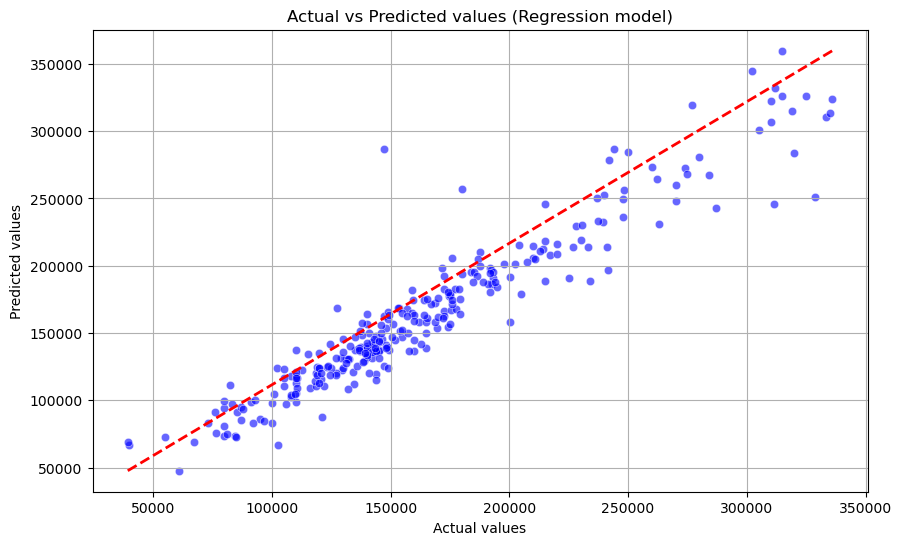

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=y_test, y=lr_test_pred, alpha=0.6, color="b") 

plt.plot ([y_test.min(), y_test.max()], [lr_test_pred.min(), lr_test_pred.max()], color="red", linestyle="--", lw=2)

plt.title("Actual vs Predicted values (Regression model)")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.grid(True)
plt.show()

According to the plot above, it indicates there is a linear relationship.  
To acertain this, i would like to evaluate the R^2 score of the model's prediction to comfirm if truly there is a strong linear relationship between them

Text(0.5, 1.0, 'Predicted VS actual values (Test set)')

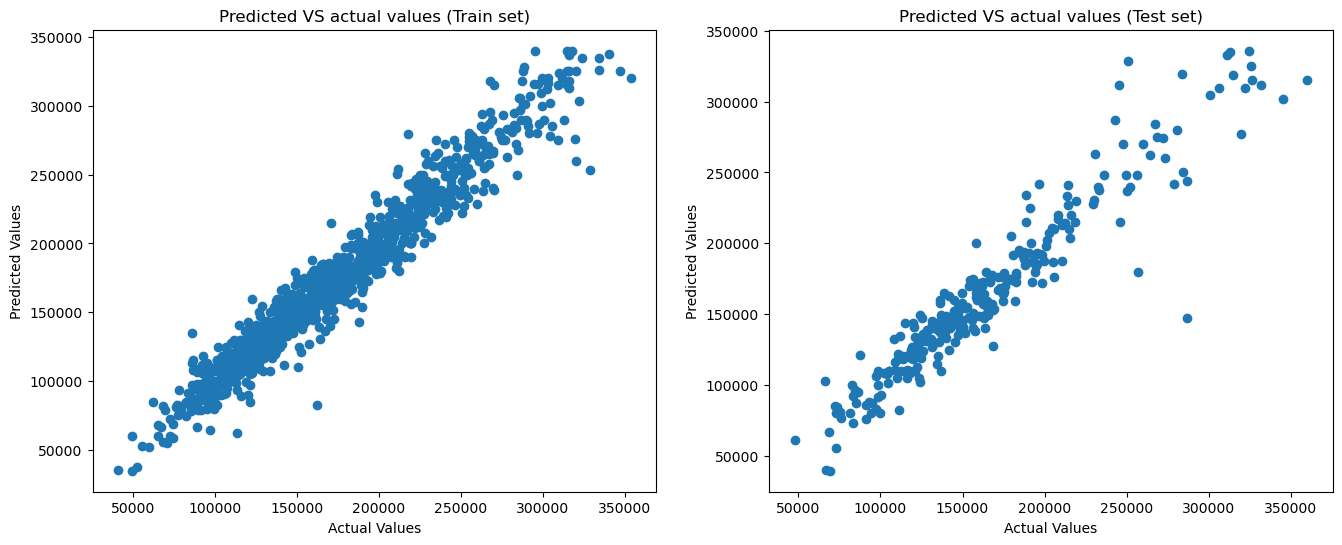

In [63]:
_, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))

ax1.scatter(lr_train_pred, y_train)
ax2.scatter(lr_test_pred, y_test)

ax1.set_ylabel("Predicted Values")
ax1.set_xlabel("Actual Values")
ax1.set_title("Predicted VS actual values (Train set)")

ax2.set_ylabel("Predicted Values")
ax2.set_xlabel("Actual Values")
ax2.set_title("Predicted VS actual values (Test set)") 

This result further justified the linear relatioship of the target variable with the other features. 

In [64]:
score = r2_score(y_test, lr_test_pred)

print (f"R-squred score: {round(score, 3)}")

R-squred score: 0.903


This confirm the said linear relationship and a strong fit.
  
And the score above shows that 90% of the variation in the dependent variable **(Y)** is explained by the independent vairiable **(X).**   
This shows that there is a strong linear relationship and strong positive fit where the data points are generally closed to regression line.  
It also show that only 10% of the variable is prone to unexplained factors  

For more proof, i would like to check for the mean-absolute-error and the mean-squared-error

In [65]:
mean_sqd_err = mse(y_test, lr_test_pred)
mean_abs_err = mae(y_test, lr_test_pred)

print (f"Mean Squared error: {np.round(mean_sqd_err, 3)}")
print (f"Mean absolute error: {np.round(mean_abs_err, 3)}")

Mean Squared error: 349699112.823
Mean absolute error: 12267.255


#### Visualising the predicted vs actual values

Text(0.5, 1.0, 'Predicted Vs True (Testing Set)')

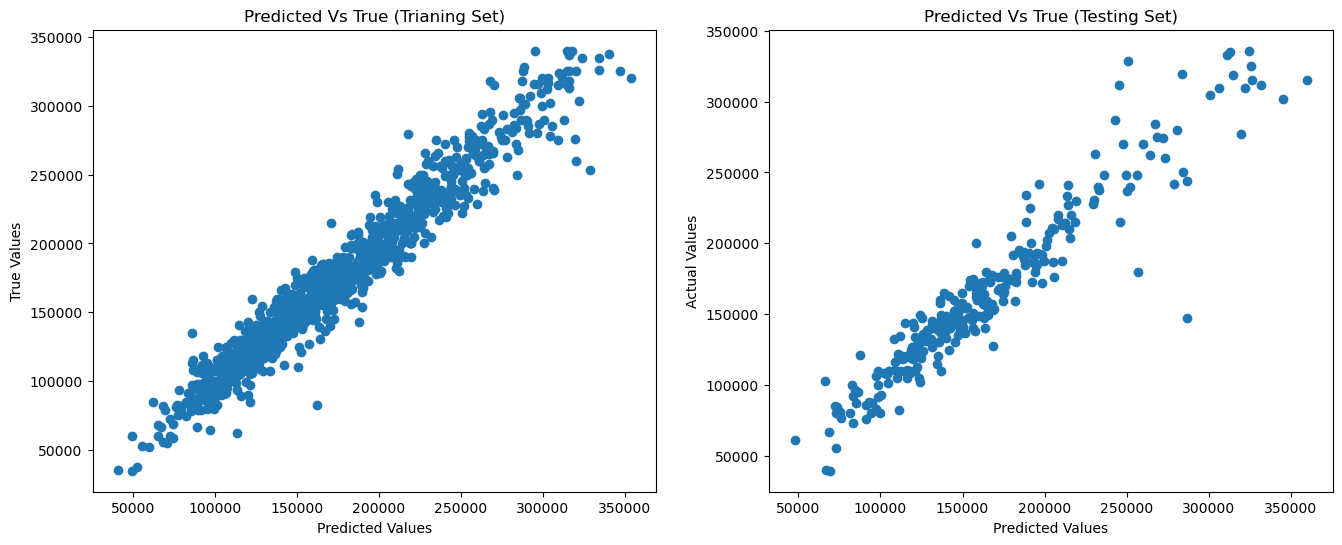

In [66]:
_, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))

ax1.scatter(lr_train_pred, y_train)
ax2.scatter(lr_test_pred, y_test)

ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("True Values")
ax1.set_title("Predicted Vs True (Trianing Set)")

ax2.set_xlabel("Predicted Values")
ax2.set_ylabel("Actual Values")
ax2.set_title("Predicted Vs True (Testing Set)")

## Inspect the Model Parameters

In [67]:
# Check model parameters

intercept = (
    lr_pipeline[-1].regressor_.intercept_
)
coefs_series = pd.Series(
    lr_pipeline[-1].regressor_.coef_, index=preprocessor.get_feature_names_out()
)

# Print the coefficients
print(f"Intercept: {intercept:.2f}")
print(f"\nCoefficients: \n{coefs_series.round(3)}")

Intercept: -1.29

Coefficients: 
num__mssubclass               0.012
num__lotfrontage              0.009
num__lotarea                  0.084
num__overallqual              0.146
num__overallcond              0.103
                              ...  
cat__salecondition_adjland    0.211
cat__salecondition_alloca     0.076
cat__salecondition_family    -0.090
cat__salecondition_normal     0.079
cat__salecondition_partial   -0.118
Length: 265, dtype: float64


#### Displaying models errors and averages

In [68]:
print(f"LR Model Error (Training): {lr_train_rmse:.3f}")
print(f"LR Model Avg. CV Error: {np.mean(cv_err):.3f}")
print(f"LR Model Std. CV Error: {np.std(cv_err):.3f}")
print(f"LR Model Test Error: {lr_test_rmse:.3f}")

LR Model Error (Training): 13645.584
LR Model Avg. CV Error: 19949.717
LR Model Std. CV Error: 1771.853
LR Model Test Error: 18700.244


## Building more Advanced Models

## Decision Tree

In [69]:
# Defining column transformer
transformer = ColumnTransformer(
    transformers=[
        ("inputer", SimpleImputer(), num_feats), 
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_feats)],
        verbose_feature_names_out=False
)

In [70]:
# Instantiate the model
dt_model = DecisionTreeRegressor(random_state=42)

dt_pipeline = make_pipeline(transformer, dt_model)

# train the model
dt_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('inputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [71]:
dt_train_pred = dt_pipeline.predict(X_train)
dt_train_pred[:5]

array([162500., 190000., 171000., 173000., 176000.])

### Getting the metrics

Getting Model error on training set

In [125]:
dt_train_rmse = rmse(y_train, dt_train_pred)
dt_train_mse = mse(y_train, dt_train_pred)
dt_train_r2_score = r2_score(y_train, dt_train_pred)
print ("DT Model Mean Squared Error (training): ", dt_train_mse)
print ("DT Model Root Mean Squared Error (training): ", dt_train_rmse)
print ("DT Model R2 Score (training): ", dt_train_r2_score)

DT Model Mean Squared Error (training):  0.0
DT Model Root Mean Squared Error (training):  0.0
DT Model R2 Score (training):  1.0


THough this result shows perfection in the model prediction. Notwitstanding, It is not ideal for a model to be `100%` accurate, will justify the result through implementing `K-fold` and `CV`

### Getting the Cross Validation Error

In [73]:
cv_errors = cross_val_score(
    lr_pipeline,
    X_train, 
    y_train,
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1
) * -1

In [74]:
np.round(cv_errors, 3)

array([20075.376, 18950.458, 18481.664, 18908.513, 23332.575])

In [75]:
print("DT Model Avg. CV Error:", np.mean(cv_errors))
print("DT Model Std. CV Error:", np.std(cv_errors))

DT Model Avg. CV Error: 19949.717363963624
DT Model Std. CV Error: 1771.8534801488843


### Evaluate the model on test set

In [76]:
# Test set prediction
dt_test_pred = dt_pipeline.predict(X_test) 

In [124]:
dt_test_rmse = rmse(y_test, dt_test_pred)
dt_test_mse = mse(y_test, dt_test_pred)
dt_test_r2_score = r2_score(y_test, dt_test_pred)
print (f"DT Model rmse (test set): {dt_test_rmse:.3f}")
print (f"DT Model mse (test set): {dt_test_mse:.3f}")
print (f"DT Model r2_score: {dt_test_r2_score:.3f}")

DT Model rmse (test set): 28963.335
DT Model mse (test set): 838874790.196
DT Model r2_score: 0.767


#### Prove the result of the decision tree model errors through visuals, feature importance, tree constrainst and complexity, and pruning

### Plotting the predicted vs actual value

Text(0.5, 1.0, 'Predicted VS actual values (Test set)')

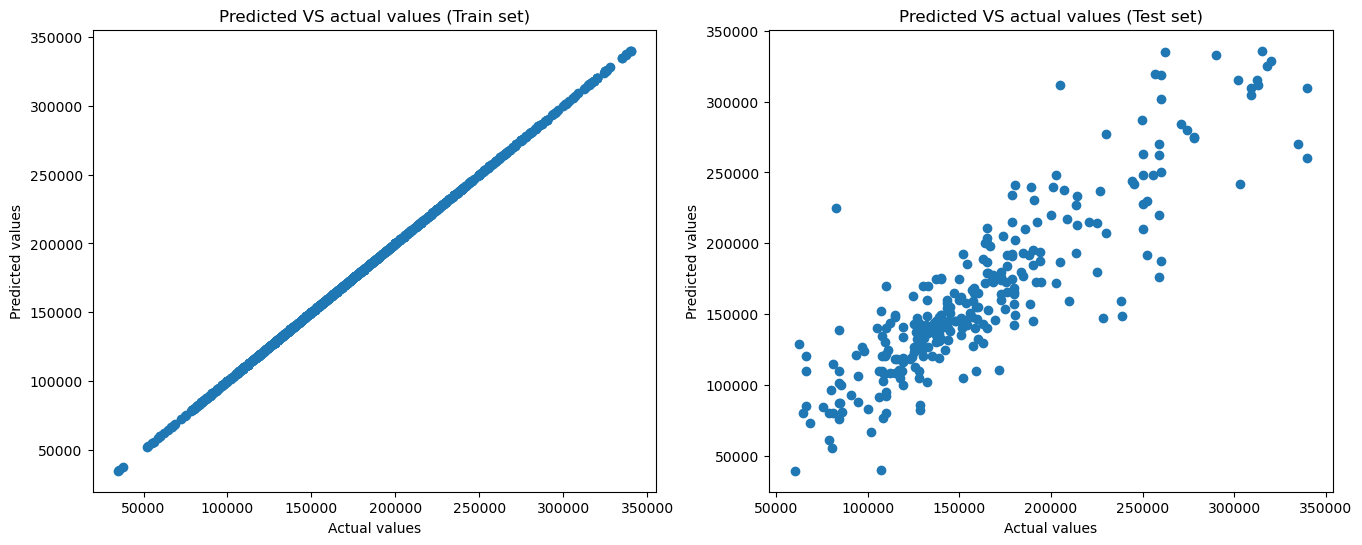

In [78]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(dt_train_pred, y_train)
ax2.scatter(dt_test_pred, y_test)

ax1.set_ylabel("Predicted values")
ax1.set_xlabel("Actual values")
ax1.set_title("Predicted VS actual values (Train set)")

ax2.set_ylabel("Predicted values")
ax2.set_xlabel("Actual values")
ax2.set_title("Predicted VS actual values (Test set)")

According to this model's visual display, it was discorvered that the train predicted and actual values all merged and are fit unlike the test set which actual tells the models accuracy on unseen data behved differect and more away from the train prediction. This shows that this model can not be chosen as the ultimate model for this project considering its prediction on unseen data 

### Decision Tree Feature impoertance

In [79]:
dt_feat_imp = pd.Series(
    dt_pipeline[-1].feature_importances_,index=transformer.get_feature_names_out()
)

print (f"{"*" * 15} FEATURE IMPORTANCE {"*" * 15}\n{dt_feat_imp.round(4)}")

*************** FEATURE IMPORTANCE ***************
mssubclass               0.0020
lotfrontage              0.0071
lotarea                  0.0082
overallqual              0.4871
overallcond              0.0075
                          ...  
salecondition_adjland    0.0000
salecondition_alloca     0.0000
salecondition_family     0.0033
salecondition_normal     0.0006
salecondition_partial    0.0001
Length: 265, dtype: float64


<Axes: >

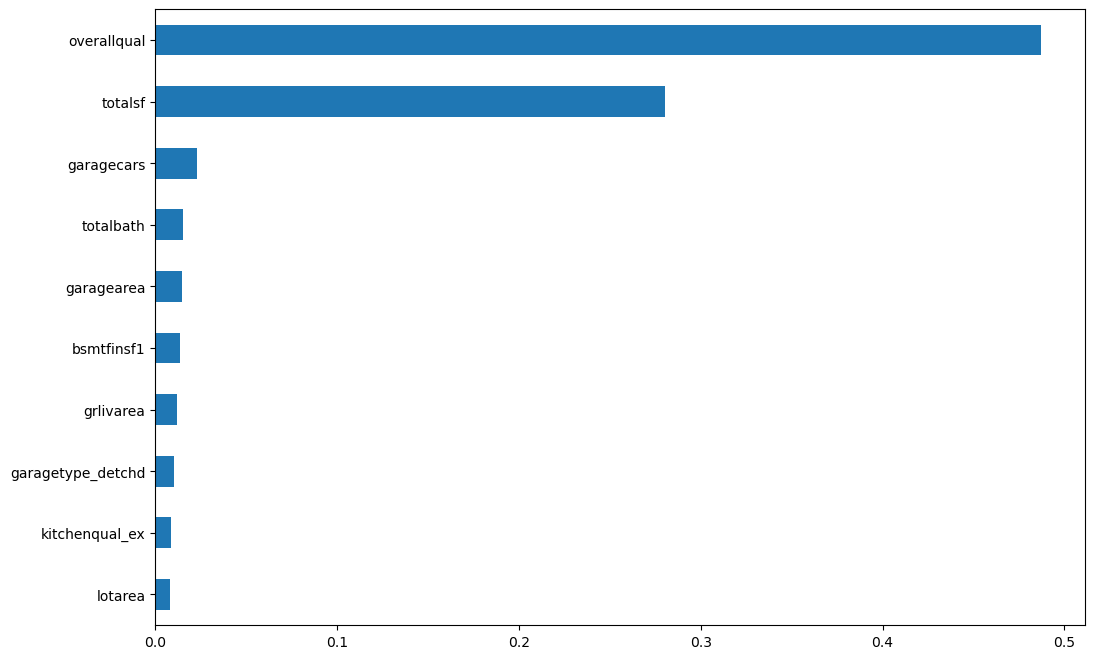

In [80]:
top_10_feat = dt_feat_imp.nlargest(10).sort_values()

top_10_feat.plot(kind="barh", figsize=(12, 8))

# for bar in top_10_feat:
#     width = bar.get_width()
#     perc = f"{width * 100:.1f}%"
#     top_10_feat.text(width + 0.005, bar.get_y(), bar.get_height()/2, label_text,
#                     ha="left", va="center", fontsize="bold")

## Random Forest

Though, from the start, the data relationship showed linearity, notwithstading, introducing radom forest model would fish out those unseen data that are not actually in linear relationship. It will also deal with the high dimensionality data and the mixed data

In [81]:
# instantiating the model
rf_model = RandomForestRegressor(n_estimators=150, random_state=42, oob_score=True, max_depth=25)

rf_pipeline = make_pipeline(transformer, rf_model)

rf_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('inputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [82]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_pred

array([163247.62      , 199363.        , 162795.18      , ...,
       232503.33333333, 243116.34666667, 144478.55333333], shape=(1117,))

#### Getting the metrics on the training set

In [83]:
rf_train_rmse = rmse(y_train, rf_train_pred)
rf_train_mse = mse(y_train, rf_train_pred)
rf_train_r2_score = r2_score(y_train, rf_train_pred)

print (f"RF Model mse (training set): {rf_train_mse}")
print (f"RF Model rmse (training set): {rf_train_rmse}")
print (f"RF Model r2_score (training set): {rf_train_r2_score}")

RF Model mse (training set): 55051655.03653065
RF Model rmse (training set): 7419.6802516369025
RF Model r2_score (training set): 0.9841818483426762


### Getting the metrics on the testing set

In [84]:
rf_test_pred = rf_pipeline.predict(X_test)
rf_test_pred[:5]

array([199608.33333333, 280988.85333333, 190275.96      , 126728.77333333,
       139532.64      ])

In [85]:
rf_test_rmse = rmse(y_test, rf_test_pred)
rf_test_mse = mse(y_test, rf_test_pred)
rf_test_r2_score = r2_score(y_test, rf_test_pred)

print (f"RF Model mse (testing set): {rf_test_mse:.3f}")
print (f"RF Model rmse (testing set): {rf_test_rmse:.3f}")
print (f"RF Model r2_score (testing set): {rf_test_r2_score:.3f}")

RF Model mse (testing set): 468970302.838
RF Model rmse (testing set): 21655.722
RF Model r2_score (testing set): 0.869


In [86]:
print (f"Difference of the r2_score in the taining and testing set: {rf_train_r2_score-rf_test_r2_score:.3f}")

Difference of the r2_score in the taining and testing set: 0.115


According to these result, there is a different between the r2_score of the training set and that of the test score. To prove this is not overfitting or giving bias result due to data leakage, there is necessity for checking the `out-of-bag` score

In [87]:
oob_score = rf_pipeline.named_steps["randomforestregressor"].oob_score_
print (f"OOB score {oob_score:.3f}")

OOB score 0.884


This result justifies the r2_score on the test set because Out-Of-Bag which give a near-accurate result due to printing out the result of the model when it leanrs from unseen data gave a result nearly as the result of the r2_score of the test set

### Cross validation errors

In [88]:
cv_errors = cross_val_score(
    rf_pipeline,
    X_train, 
    y_train,
    cv=5, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1
) * -1

In [89]:
np.round(cv_errors, 3)

array([21584.852, 21158.841, 21121.922, 18630.398, 19375.176])

#### Visualizing the predicted vs actual values through scatter plot

Text(0.5, 1.0, 'Predicted VS actual values (Test set)')

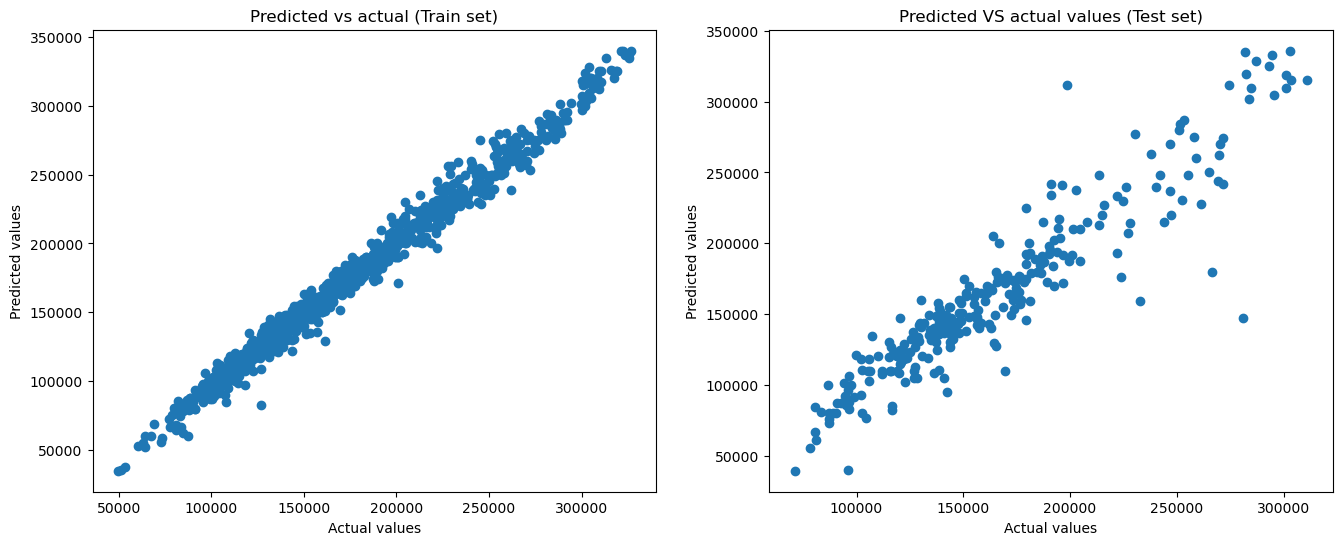

In [90]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(rf_train_pred, y_train)
ax2.scatter(rf_test_pred, y_test)

ax1.set_ylabel("Predicted values")
ax1.set_xlabel("Actual values")
ax1.set_title("Predicted vs actual (Train set)")

ax2.set_ylabel("Predicted values")
ax2.set_xlabel("Actual values")
ax2.set_title("Predicted VS actual values (Test set)")

According to this result, the prediction of the model from unseen data to the trainig set almost take the same shape and points. This is a sign that the model would be put into consideration when the best model is being deliberate on.

#### Checking the feature relevance and their heirachy of their influences on the target feature (feature importance)

In [91]:
feat_importance = pd.Series(
    rf_pipeline[-1].feature_importances_,index=transformer.get_feature_names_out()

)

print (f"Feature importances\n{feat_importance.round(3)}")

Feature importances
mssubclass               0.002
lotfrontage              0.006
lotarea                  0.013
overallqual              0.351
overallcond              0.007
                         ...  
salecondition_adjland    0.000
salecondition_alloca     0.000
salecondition_family     0.001
salecondition_normal     0.001
salecondition_partial    0.000
Length: 265, dtype: float64


## Evaluate Gradien Boosting

In [92]:
gb_model = GradientBoostingRegressor(max_depth=8, random_state=42)

gb_pipeline = make_pipeline(transformer, gb_model)

Find uptimum learning rate and the n_estimator

In [93]:
gb_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('gradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('inputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [94]:
gb_train_pred = gb_pipeline.predict(X_train)

np.round(gb_train_pred[:5], 3)

array([161458.015, 190694.674, 169358.468, 173665.811, 175895.508])

Getting metrics on the training set

In [95]:
gb_train_rmse = rmse(y_train, gb_train_pred) 
gb_train_mse = mse(y_train, gb_train_pred) 
gb_train_r2_score = r2_score(y_train, gb_train_pred)

print (("*" * 10), "TRAINING SET METRICS RESULTS", ("*" * 10))
print (f"GB Model RMSE: {gb_train_rmse}")
print (f"gb Model MSE: {gb_train_mse}")
print (f"gb Model r2_score: {gb_train_r2_score}")

********** TRAINING SET METRICS RESULTS **********
GB Model RMSE: 527.6160784207743
gb Model MSE: 278378.72620811674
gb Model r2_score: 0.9999200126334729


### Checking the GB model error on test set

In [96]:
gb_test_pred = gb_pipeline.predict(X_test)
np.round(gb_test_pred[:5], 3)

array([202003.799, 264080.6  , 182069.805, 118574.969, 138163.881])

In [97]:
gb_test_rmse = rmse(y_test, gb_test_pred) 
gb_test_mse = mse(y_test, gb_test_pred) 
gb_test_r2_score = r2_score(y_test, gb_test_pred)

print (("*" * 10), "TESTING SET METRICS RESULTS", ("*" * 10))
print (f"GB Model RMSE: {gb_test_rmse:.3f}")
print (f"gb Model MSE: {gb_test_mse:.3f}")
print (f"gb Model r2_score: {np.round(gb_test_r2_score, 3)}")

********** TESTING SET METRICS RESULTS **********
GB Model RMSE: 21993.552
gb Model MSE: 483716335.841
gb Model r2_score: 0.865


### Cross Val Errors

In [98]:
cv_err = cross_val_score(
    gb_pipeline, 
    X_train,
    y_train,
    cv=5, 
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

np.round(cv_err, 3)

array([24220.629, 22307.863, 23727.15 , 19209.509, 21171.085])

In [99]:
print (f"GB Avg Model cv_errors: {np.mean(cv_err):.3f}")
print (f"GB STD Model cv_errors: {np.std(cv_err):.3f}")

GB Avg Model cv_errors: 22127.247
GB STD Model cv_errors: 1811.187


Scatter plots displaying the predicted values vs actual values in both training and testing set

Text(0.5, 1.0, 'Predicted VS actual values (Test set)')

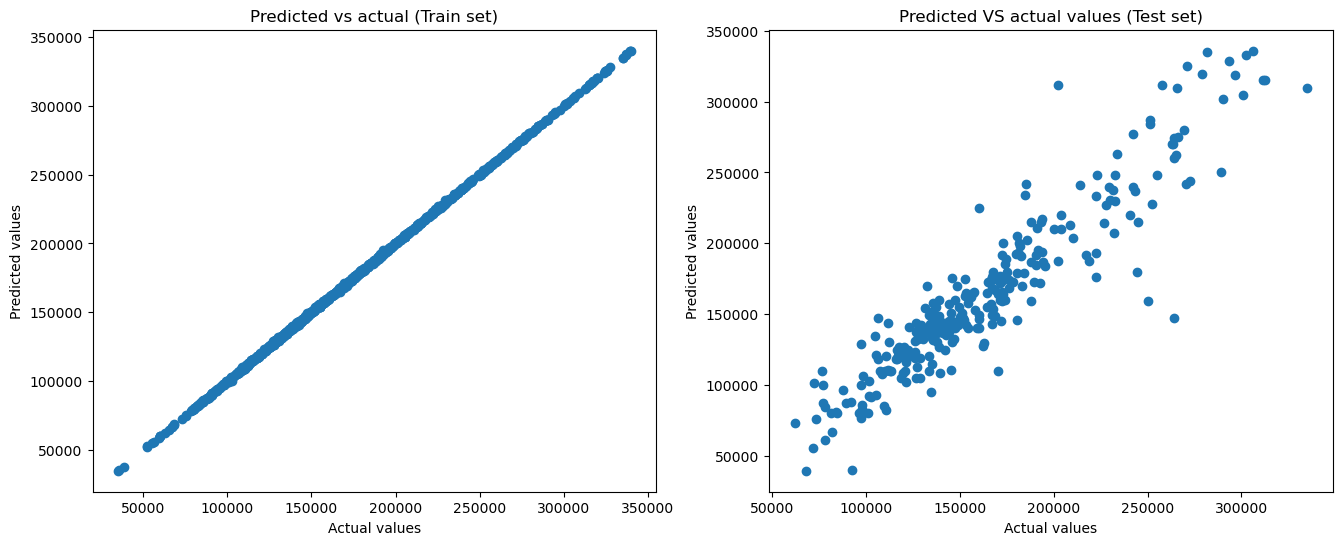

In [100]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(gb_train_pred, y_train)
ax2.scatter(gb_test_pred, y_test)

ax1.set_ylabel("Predicted values")
ax1.set_xlabel("Actual values")
ax1.set_title("Predicted vs actual (Train set)")

ax2.set_ylabel("Predicted values")
ax2.set_xlabel("Actual values")
ax2.set_title("Predicted VS actual values (Test set)")

According to this result, it is non-negatiable that both GradientBoostingRegressor and DecisionTreeRegressor models overfitted in their prediction. When they predicted accurately on the data made available to them but predicted poorly or close to accurate the training set when fed with unsean data.

#### Inspect model parameters

In [101]:
gb_feat_imp = pd.Series(
    gb_pipeline[-1].feature_importances_, index=transformer.get_feature_names_out()
)

print ("Feature Importance\n", round(gb_feat_imp, 3))

Feature Importance
 mssubclass               0.002
lotfrontage              0.006
lotarea                  0.014
overallqual              0.462
overallcond              0.008
                         ...  
salecondition_adjland    0.000
salecondition_alloca     0.000
salecondition_family     0.002
salecondition_normal     0.001
salecondition_partial    0.000
Length: 265, dtype: float64


<Axes: >

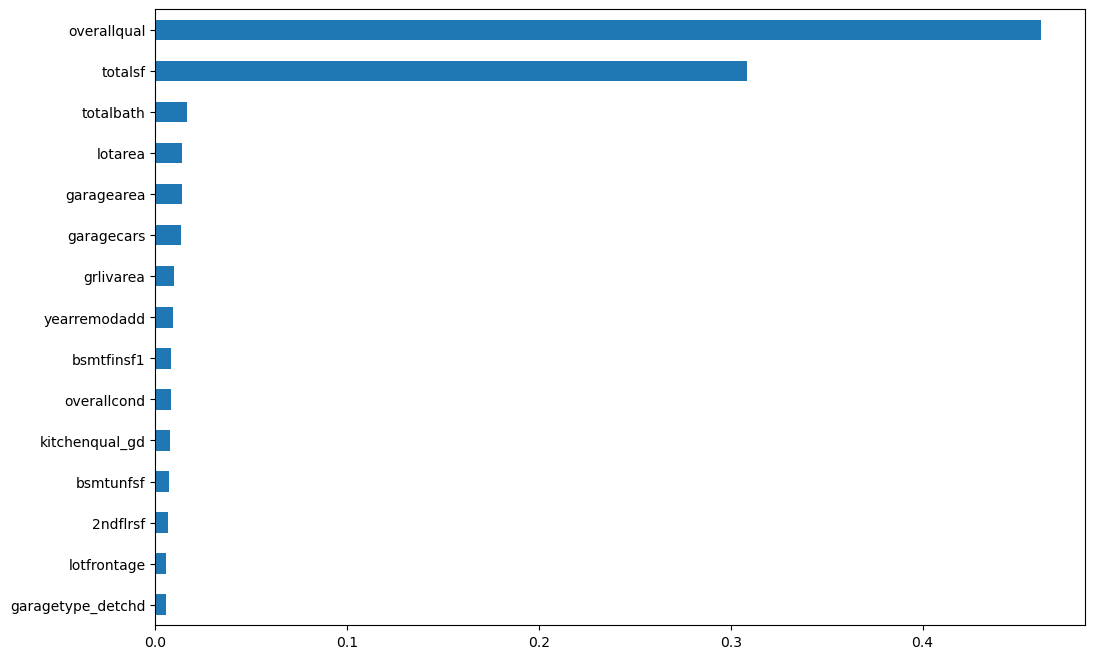

In [102]:
top_15_feat = gb_feat_imp.nlargest(15).sort_values()

top_15_feat.plot(kind="barh", figsize=(12, 8))

### Models' Metrics comparison

#### Models' Training set metrics

In [155]:
tr_metrics = {
    "Models": ["Linear Regression", "Random Foreest Regressor", "Decision Tree", "Gradient Boosting"],
    "Tr_RMSE": [round(lr_train_rmse, 1), round(rf_train_rmse,1), round(dt_train_rmse,1), round(gb_train_rmse, 1)],
    "Tr_MSE": [round(lr_train_mse,1), round(rf_train_mse,1), round(dt_train_mse, 1), round(gb_train_mse, 1)],
    "Tr_R2_Score": [round(lr_train_r2_score,2), round(rf_train_r2_score, 2), round(dt_train_r2_score,2), round(gb_train_r2_score, 2)]
}

In [156]:
tr_metric_df = pd.DataFrame(tr_metrics)

In [157]:
print ("*" * 20, " Models' training set metrics ", "*" * 20)
tr_metric_df

********************  Models' training set metrics  ********************


,Models,Tr_RMSE,Tr_MSE,Tr_R2_Score
0,Linear Regression,13645.6,1.862020e+08,0.95
1,Random Foreest Regressor,41579.2,1.728834e+09,0.50
2,Decision Tree,0.0,0.000000e+00,1.00
3,Gradient Boosting,527.6,2.783787e+05,1.00


#### Models' Testing set metrics

In [158]:
te_metrics = {
    "Models": ["Linear Regression", "Random Foreest Regressor", "Decision Tree", "Gradient Boosting"],
    "Te_RMSE": [round(lr_test_rmse, 1), round(rf_test_rmse,1), round(dt_test_rmse,1), round(gb_test_rmse, 1)],
    "Te_MSE": [round(lr_test_mse,1), round(rf_test_mse,1), round(dt_test_mse, 1), round(gb_test_mse, 1)],
    "Te_R2_Score": [round(lr_test_r2_score,2), round(rf_test_r2_score, 2), round(dt_test_r2_score,2), round(gb_test_r2_score, 2)]
}

In [159]:
te_metric_df = pd.DataFrame(te_metrics)

In [160]:
print ("*" * 20, " Models' testing set metrics ", "*" * 20)
te_metric_df

********************  Models' testing set metrics  ********************


,Models,Te_RMSE,Te_MSE,Te_R2_Score
0,Linear Regression,18700.2,349699112.8,0.90
1,Random Foreest Regressor,21655.7,468970302.8,0.87
2,Decision Tree,28963.3,838874790.2,0.77
3,Gradient Boosting,21993.6,483716335.8,0.87


### Visualizing the models' metrics performance given from the unseen data

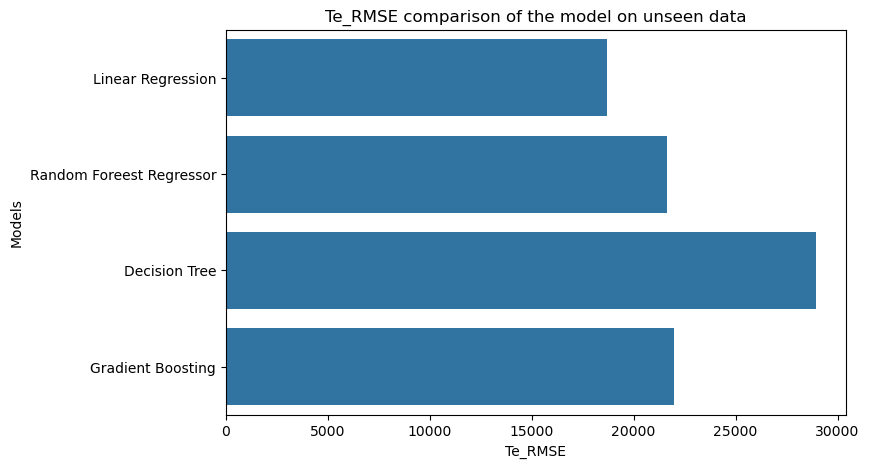

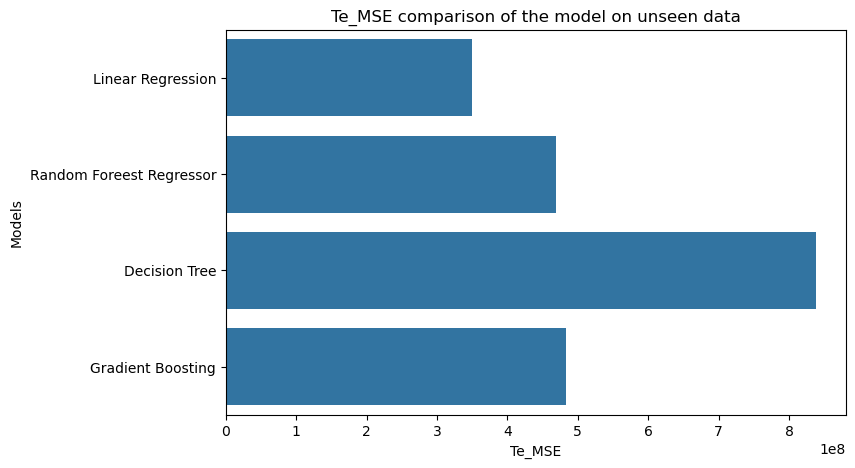

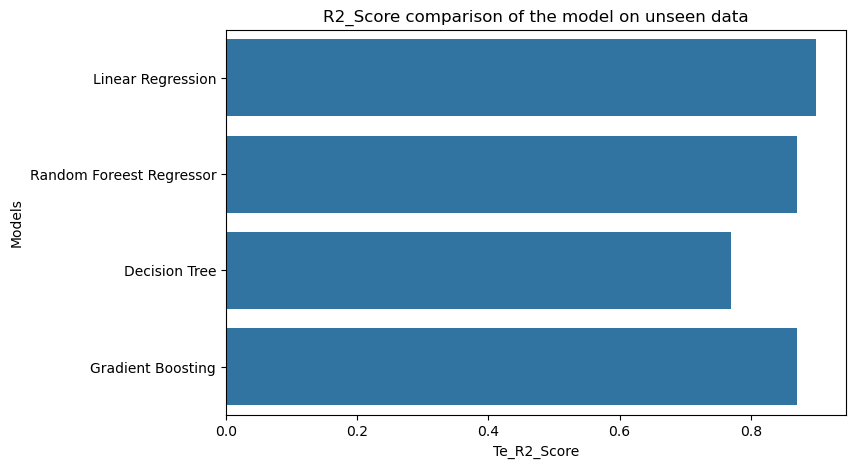

In [161]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Te_RMSE", y="Models", data=te_metric_df)
plt.title("Te_RMSE comparison of the model on unseen data")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Te_MSE", y="Models", data=te_metric_df)
plt.title("Te_MSE comparison of the model on unseen data")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Te_R2_Score", y="Models", data=te_metric_df)
plt.title("R2_Score comparison of the model on unseen data")
plt.show()

### Add KMEANS to RandomForestRegressor Model

In [103]:
from sklearn.cluster import KMeans
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import StandardScaler

In [104]:
class CustomKMeans(KMeans):
    def get_feature_names_out(self, input_features=None):
        feat_names = [f"distance_{i}" for i in range(self.n_clusters)] + [
            "cluster_label"
        ]
        return feat_names

    def _transform(self, X):
        distances = super()._transform(X)
        labels = self.predict(X).reshape(-1, 1)
        feats = np.hstack((distances, labels))
        return feats

    def transform(self, X):
        return self._transform(X)

In [105]:
transformer

,transformers,"[('inputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [106]:
kmeans_pipe = make_pipeline(
    transformer,
    StandardScaler(),
    CustomKMeans(8, random_state=42)
)

In [107]:
kmeans_pipe.fit_transform(X)

array([[18.90960333, 16.01160341, 12.76608647, ..., 10.66923339,
        12.31071358,  4.        ],
       [23.10916865, 20.85961551, 18.19271504, ..., 16.69142502,
        18.24813052,  5.        ],
       [19.31075763, 16.84942437, 12.70197427, ..., 11.5124811 ,
        13.18875892,  4.        ],
       ...,
       [28.32257213, 25.69138416, 24.0977364 , ..., 23.1022021 ,
        23.0764155 ,  4.        ],
       [22.23617201, 18.2784844 , 16.33782876, ..., 13.00098405,
        15.04855316,  6.        ],
       [21.58348271, 17.72955447, 15.20310223, ..., 12.57042218,
        14.98401699,  5.        ]], shape=(1397, 9))

#### Create feature union to combine k means features with normal features

In [108]:
feat_union = FeatureUnion(
    [
        ("base", transformer),
        ("kmeans", kmeans_pipe),
    ], 
    verbose_feature_names_out = False
)

#### OneHotEncoder for kmeans labels

In [109]:
kmeans_label_encode = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [-1])], 
    verbose_feature_names_out=False 
)

In [110]:
kmeans_pipe

,steps,"[('columntransformer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('inputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [166]:
hrf_model = RandomForestRegressor(max_depth=8)

hrf_pipeline = make_pipeline(feat_union, kmeans_label_encode, hrf_model)
hrf_pipeline.fit(X_train, y_train)

,steps,"[('featureunion', ...), ('columntransformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base', ...), ('kmeans', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'mean'


In [172]:
hrf_train_pred = hrf_pipeline.predict(X_train) 
np.round(hrf_train_pred[:5], 3)

array([136547.931, 229794.696, 136547.931, 213197.715, 213197.715])

### Metrics after applying KMeans

In [173]:
hrf_train_rmse = rmse(y_train, hrf_train_pred) 
hrf_train_mse = mse(y_train, hrf_train_pred)
hrf_train_r2_score = r2_score(y_train, hrf_train_pred)

print ("*" * 15, "RF metrics on training set after applying kmeans", "*" * 15)
print (f"RF Model mse (training set): {hrf_train_rmse}")
print (f"RF Model rmse (training set): {hrf_train_mse}")
print (f"RF Model r2_score (training set): {hrf_train_r2_score}")

*************** RF metrics on training set after applying kmeans ***************
RF Model mse (training set): 41579.64652933201
RF Model rmse (training set): 1728867005.504191
RF Model r2_score (training set): 0.5032396306657514


#### Evaluating same on test set

In [174]:
hrf_test_pred = rf_pipeline.predict(X_test) 
np.round(hrf_test_pred[:5], 3)

array([230912.424, 230912.424, 136397.772, 159174.355, 159174.355])

In [175]:
hrf_test_rmse = rmse(y_test, hrf_test_pred) 
hrf_test_mse = mse(y_test, hrf_test_pred)
hrf_test_r2_score = r2_score(y_test, hrf_test_pred)

print ("*" * 15, "RF metrics on training set after applying kmeans", "*" * 15)
print (f"RF Model mse (testing set): {round(hrf_test_rmse, 3)}")
print (f"RF Model rmse (testing set): {round(hrf_test_mse, 3)}")
print (f"RF Model r2_score (testing set): {round(hrf_test_r2_score, 3)}")

*************** RF metrics on training set after applying kmeans ***************
RF Model mse (testing set): 42527.972
RF Model rmse (testing set): 1808628424.669
RF Model r2_score (testing set): 0.497


### Cross Validation Error

In [176]:
cv_err = cross_val_score(
    hrf_pipeline, 
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1,
    cv=5
) * -1

In [177]:
np.round(cv_err, 3)

array([42112.116, 43924.281, 41897.815, 43806.284, 39946.646])

In [178]:
print (f"RF model AVG cv_error: {np.mean(cv_err):.3f}")
print (f"RF model STD cv_error: {np.std(cv_err):.3f}")

RF model AVG cv_error: 42337.428
RF model STD cv_error: 1458.458


#### Comparing Random forest regressor model metrics between before and after hyperparameter tuning

In [179]:
hrf_metrics = {
    "Models": ["Random Foreest Regressor", "Hyper_param RFR"],
    "Te_RMSE": [round(rf_test_rmse, 1), round(hrf_test_rmse,1)],
    "Te_MSE": [round(rf_test_mse,1), round(hrf_test_mse,1)],
    "Te_R2_Score": [round(rf_test_r2_score,2), round(hrf_test_r2_score, 2)]
}

In [180]:
hrf_metrics_df = pd.DataFrame(hrf_metrics)
print ("*" * 20, "Hyper_param RFR metrics Comparison", "*"*20)
hrf_metrics_df

******************** Hyper_param RFR metrics Comparison ********************


,Models,Te_RMSE,Te_MSE,Te_R2_Score
0,Random Foreest Regressor,21655.7,4.689703e+08,0.87
1,Hyper_param RFR,42528.0,1.808628e+09,0.50


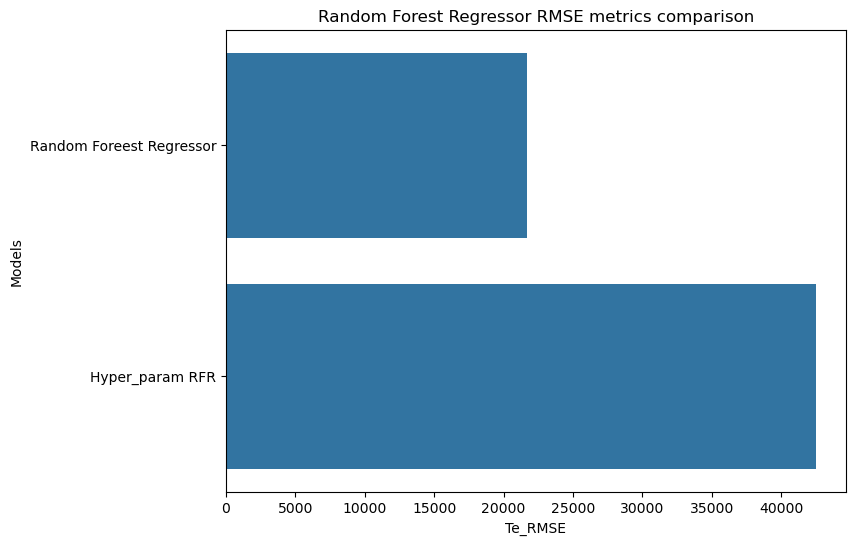

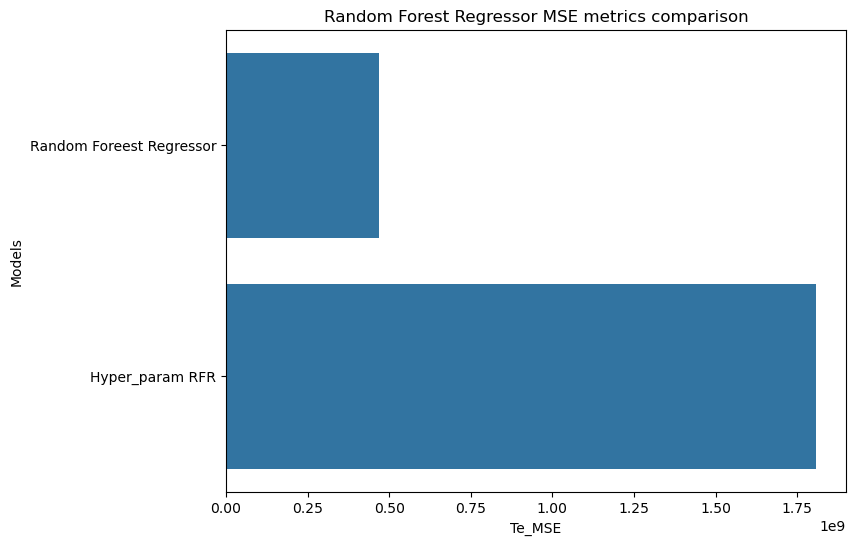

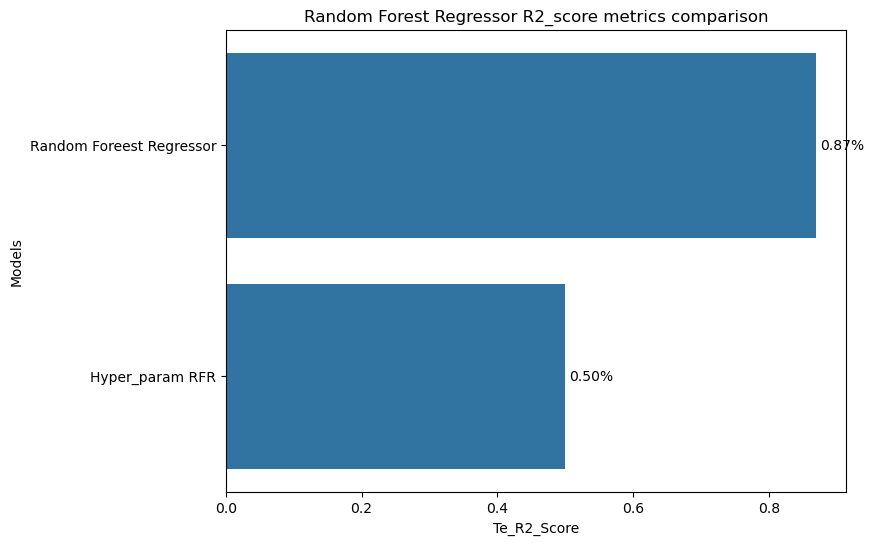

In [187]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Te_RMSE", y="Models", data=hrf_metrics_df)
plt.title("Random Forest Regressor RMSE metrics comparison")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x="Te_MSE", y="Models", data=hrf_metrics_df)
plt.title("Random Forest Regressor MSE metrics comparison")
plt.show()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x="Te_R2_Score", y="Models", data=hrf_metrics_df)
plt.title("Random Forest Regressor R2_score metrics comparison")
ax.bar_label(ax.containers[0], fmt='{:.2f}%', padding=3)
plt.show()